# Attention-cues
## 查询、键和值

自主性的与非自主性的注意力提示解释了人类的注意力的方式，
下面来看看如何通过这两种注意力提示，
用神经网络来设计注意力机制的框架，

首先，考虑一个相对简单的状况，
即只使用非自主性提示。
要想将选择偏向于感官输入，
则可以简单地使用参数化的全连接层，
甚至是非参数化的最大汇聚层或平均汇聚层。

因此，“是否包含自主性提示”将注意力机制与全连接层或汇聚层区别开来。
在注意力机制的背景下，自主性提示被称为*查询*（query）。
给定任何查询，注意力机制通过*注意力汇聚*（attention pooling）
将选择引导至*感官输入*（sensory inputs，例如中间特征表示）。
在注意力机制中，这些感官输入被称为*值*（value）。
更通俗的解释，每个值都与一个*键*（key）配对，
这可以想象为感官输入的非自主提示。
可以通过设计注意力汇聚的方式，
便于给定的查询（自主性提示）与键（非自主性提示）进行匹配，
这将引导得出最匹配的值（感官输入）。

## 注意力的可视化

平均汇聚层可以被视为输入的加权平均值，
其中各输入的权重是一样的。
实际上，注意力汇聚得到的是加权平均的总和值，
其中权重是在给定的查询和不同的键之间计算得出的。


In [1]:
import torch
from d2l import torch as d2l

为了可视化注意力权重，需要定义一个`show_heatmaps`函数。
其输入`matrices`的形状是
（要显示的行数，要显示的列数，查询的数目，键的数目）。

In [2]:
#@save  # 装饰器：d2l库专用，把这个函数保存到d2l工具库中，方便后续直接调用
def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5),
                  cmap='Reds'):
    """显示矩阵热图"""
    d2l.use_svg_display()  # d2l工具：让图片用SVG矢量图显示，更清晰、无锯齿
    # 从输入的 matrices 里，取出第 0 维长度作为行数，取出第 1 维长度作为列数，分别存到 num_rows 和 num_cols 里。
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    # fig：整张大图；axes：子图数组（二维数组，对应每个热图）
    # sharex/sharey=True：所有子图共享X/Y轴刻度，更整洁
    # squeeze=False：保证即使是1张图，axes也保持二维格式，避免报错
    fig, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize,
                                 sharex=True, sharey=True, squeeze=False)
    # 双层循环：遍历每一行、每一列的子图
    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            # .detach()：从计算图中分离张量（禁止梯度计算，绘图必须）
            # .numpy()：把PyTorch张量转成numpy数组（matplotlib只认numpy）
            # cmap：颜色方案，默认Reds是红色系
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            # 仅在**最后一行**添加X轴标签（避免重复画标签）
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            # 仅在**第一列**添加Y轴标签（避免重复画标签）
            if j == 0:
                ax.set_ylabel(ylabel)
            # 如果传入了标题，给每个子图设置标题
            if titles:
                ax.set_title(titles[j])
    fig.colorbar(pcm, ax=axes, shrink=0.6);

下面使用一个简单的例子进行演示。
在本例子中，仅当查询和键相同时，注意力权重为1，否则为0。


attention_weights = torch.eye(10).reshape((1, 1, 10, 10))

将

```
dim=0 (行): 10
dim=1 (列): 10

[
  [1,0,0,0,0,0,0,0,0,0],
  [0,1,0,0,0,0,0,0,0,0],
  [0,0,1,0,0,0,0,0,0,0],
  [0,0,0,1,0,0,0,0,0,0],
  [0,0,0,0,1,0,0,0,0,0],
  [0,0,0,0,0,1,0,0,0,0],
  [0,0,0,0,0,0,1,0,0,0],
  [0,0,0,0,0,0,0,1,0,0],
  [0,0,0,0,0,0,0,0,1,0],
  [0,0,0,0,0,0,0,0,0,1]
]
```

改为

```
dim=0: 1    ← 第1层包装
  dim=1: 1  ← 第2层包装
    dim=2: 10  ← 原来的行
      dim=3: 10  ← 原来的列

[  # dim=0
  [  # dim=1
    [  # dim=2（第0行）
      [1,0,0,0,0,0,0,0,0,0],
      [0,1,0,0,0,0,0,0,0,0],
      [0,0,1,0,0,0,0,0,0,0],
      [0,0,0,1,0,0,0,0,0,0],
      [0,0,0,0,1,0,0,0,0,0],
      [0,0,0,0,0,1,0,0,0,0],
      [0,0,0,0,0,0,1,0,0,0],
      [0,0,0,0,0,0,0,1,0,0],
      [0,0,0,0,0,0,0,0,1,0],
      [0,0,0,0,0,0,0,0,0,1]
    ]
  ]
]
```

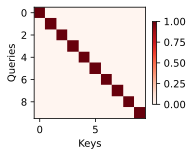

In [3]:
# torch.eye(n)创建一个 n×n 的单位矩阵（对角线为 1，其余为 0）
attention_weights = torch.eye(10).reshape((1, 1, 10, 10))
show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries')

在机器翻译中通过解码序列词元时，其自主性提示可能是什么？非自主性提示和感官输入又是什么？

自主性提示（Autonomous Prompt）

在逐词解码生成译文时，自主性提示指：模型已经生成的前序译文词元（prefix tokens）。
简单说：模型自己 “刚刚说过的话”，作为下一步生成的提示。

非自主性提示（Non-Autonomous Prompt）

指不是模型自己生成、而是外部给定的固定上下文。

感官输入（Sensory Input）

在序列解码框架下，感官输入 = 模型能 “感知” 到的全部外部信息。
可以理解为：模型在生成每个词时，能 “看到” 的全部外部信号。
它包含了非自主性提示，并更偏向底层表示层面。

自主性提示：模型自己已经生成的译文前缀
非自主性提示：外部给定的源句编码 + 任务信息
感官输入：模型在解码时能访问的全部外部特征（源句表示等）

豆包现在的生成机制，三者都在用，只是叫法和场景不一样。

自主性提示 → 正在大量用

聊天时，豆包已经说出去的上文，会作为下一句话的提示。

非自主性提示 → 也在用

系统提示词（比如 “你是豆包，礼貌、有用”）一个简单的skill，
当你系统性要求豆包以某种固定格式回答，
这些是外部给的、不是生成的提示，就是非自主性提示。

感官输入 → 对应模型底层的输入信息

你的问题文本,历史对话,豆包联网检索的信息,
全部被转成词向量，喂给模型的全部外部信息。

随机生成一个10×10矩阵并使用softmax运算来确保每行都是有效的概率分布，然后可视化输出注意力权重。
$softmax(x_i)=\frac{\exp(x_j)}{\sum_{k}\exp(x_k)}$.

In [11]:
# 生成 10x10 正态分布随机张量
attention_weights_random = torch.randn(10, 10)

# 对 最后一个维度 做 softmax（注意力权重标准做法）
attention_weights = torch.softmax(attention_weights_random, dim=-1)

# 改成热力图需要的 4维形状 (1,1,10,10)
attention_weights_random = attention_weights_random.reshape(1, 1, 10, 10)

# 极简代码演示
# # 直接生成：正态分布 → softmax → 4维 (1,1,10,10)
# attention_weights = torch.softmax(torch.randn(10, 10), dim=-1).reshape(1,1,10,10)

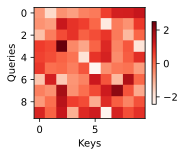

In [12]:
# 作图
show_heatmaps(attention_weights_random, xlabel='Keys', ylabel='Queries')

本节注重学习了热图绘制模块，也提前了解了一些自主性提示，非自主性提示，感官输入的相关信息

遇到报错:

```
AttributeError                            Traceback (most recent call last)
Cell In[6], line 3
      1 # 改变矩阵的维度并作图
      2 attention_weights_random.reshape((1, 1, 10, 10))
----> 3 show_heatmaps(attention_weights_random, xlabel='Keys', ylabel='Queries')

Cell In[2], line 19, in show_heatmaps(matrices, xlabel, ylabel, titles, figsize, cmap)
     14 for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
     15     for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
     16         # .detach()：从计算图中分离张量（禁止梯度计算，绘图必须）
     17         # .numpy()：把PyTorch张量转成numpy数组（matplotlib只认numpy）
     18         # cmap：颜色方案，默认Reds是红色系
---> 19         pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
     20         # 仅在**最后一行**添加X轴标签（避免重复画标签）
     21         if i == num_rows - 1:

AttributeError: 'numpy.float64' object has no attribute 'detach'
```

attention_weights_random 是一个 numpy 数组（numpy.float64），不是 PyTorch 张量，所以没有 .detach() 方法，不能直接传入。
解决方法不用numpy,直接生成pytorch张量